# Previous Config

In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import torchmetrics

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

In [99]:
# -- PARÂMETROS GLOBAIS --
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Parâmetros do dataset e treinamento
DATA_DIR = "./data"
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 3  # Oxford Pet: 0 (Pet), 1 (Fundo), 2 (Borda)
LEARNING_RATE = 0.001
NUM_EPOCHS = 5

# Dataset reduzido para treino
NUM_TRAIN_SAMPLES = 3000
NUM_VAL_SAMPLES = 600

print(f"Device: {DEVICE}")

Device: cuda


In [100]:
# Transforms nas imagens
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Transforms nas masks
target_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])

def process_target(target):
    target = torch.squeeze(target)
    # Valores originais usam 1-index 
    # CrossEntropyLoss usa 0-index
    target = target - 1
    return target.long()

# Carregando o dataset
full_dataset = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=lambda t: process_target(target_transform(t))
)

# Subsets reduzidos para treino e validação por index
indices = torch.randperm(len(full_dataset)).tolist()
train_dataset = Subset(full_dataset, indices[:NUM_TRAIN_SAMPLES])
val_dataset = Subset(full_dataset, indices[NUM_TRAIN_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total: {len(train_dataset)} imagens de treino e {len(val_dataset)} de validação.")

Total: 3000 imagens de treino e 600 de validação.


# Unet Implementation Torch

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits
    
print("ok")

ok


In [102]:
# Supondo que as imagens de entrada são RGB (3 canais)
# e o dataset Oxford-IIIT Pet tem 3 classes de segmentação (pet, background, border)
n_channels = 3
n_classes = 3

model = UNet(n_channels=n_channels, n_classes=n_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)



UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
 

In [103]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    model.to(DEVICE)
    best_loss = float('inf')
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        model.train()
        running_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            if isinstance(outputs, dict): # FCN() -> dict
                outputs = outputs['out']
            
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
                
                outputs = model(images)
                if isinstance(outputs, dict):
                    outputs = outputs['out']

                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

        val_loss = val_loss / len(val_loader.dataset)
        
        end_time = time.time()
        epoch_duration = end_time - start_time
        
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Duração: {epoch_duration:.2f}s - "
              f"Train Loss: {epoch_loss:.4f} - "
              f"Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), f"{model.__class__.__name__}_best.pth")
            print(f"  -> Modelo salvo com a melhor val loss: {best_loss:.4f}")
            
    return model

In [104]:
print("Training : U-Net")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

trained_unet = train_model(model, train_loader, val_loader, criterion, optimizer, 25)


Training : U-Net


Epoch 1/25 [Val]: 100%|██████████| 38/38 [00:03<00:00, 10.13it/s]


Epoch 1/25 - Duração: 44.48s - Train Loss: 0.6369 - Val Loss: 0.6273
  -> Modelo salvo com a melhor val loss: 0.6273


Epoch 2/25 [Val]: 100%|██████████| 38/38 [00:03<00:00, 10.17it/s]


Epoch 2/25 - Duração: 44.15s - Train Loss: 0.4915 - Val Loss: 0.4704
  -> Modelo salvo com a melhor val loss: 0.4704


...

Epoch 23/25 - Duração: 45.22s - Train Loss: 0.1544 - Val Loss: 0.3115


Epoch 24/25 [Val]: 100%|██████████| 38/38 [00:03<00:00,  9.85it/s]


Epoch 24/25 - Duração: 44.73s - Train Loss: 0.1469 - Val Loss: 0.3171


Epoch 25/25 [Val]: 100%|██████████| 38/38 [00:03<00:00,  9.72it/s]

Epoch 25/25 - Duração: 45.75s - Train Loss: 0.1509 - Val Loss: 0.3469


In [105]:
def calculate_iou_manual(preds, targets, num_classes):
    preds = torch.argmax(preds, dim=1)
    
    preds = preds.view(-1)
    targets = targets.view(-1)
    
    iou_per_class = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (targets == cls)
        
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        
        if union == 0:
            iou = 1.0
        else:
            iou = intersection / union
            
        iou_per_class.append(iou)
        
    return np.mean(iou_per_class)

def evaluate_minibatch(model, loader):
    model.eval()
    model.to(DEVICE)
    
    # usando torchmetrics
    # jaccard: IoU
    jaccard = torchmetrics.JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
    
    with torch.no_grad():
        # um batch de validation
        images, masks = next(iter(loader))
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        outputs = model(images)
        if isinstance(outputs, dict):
            outputs = outputs['out']
            
        # metrica
        iou_manual = calculate_iou_manual(outputs, masks, NUM_CLASSES)
        
        # metricas com torchmetrics
        tm_iou = jaccard(outputs, masks)
        tm_acc = accuracy(outputs, masks)
        
        print(f"--- Avaliação de um Minibatch para '{model.__class__.__name__}' ---")
        print(f"IoU (medio) calculado manualmente: {iou_manual:.4f}")
        print(f"IoU (medio) com Torchmetrics:     {tm_iou.item():.4f}")
        print(f"Acurácia (media) com Torchmetrics: {tm_acc.item():.4f}\n")

evaluate_minibatch(trained_unet, val_loader)


--- Avaliação de um Minibatch para 'UNet' ---
IoU (medio) calculado manualmente: 0.7067
IoU (medio) com Torchmetrics:     0.7067
Acurácia (media) com Torchmetrics: 0.8040



In [106]:
# Utils para visualização

def unnormalize_image(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

def mask_to_rgb(mask, num_classes=NUM_CLASSES):
    colors = torch.tensor([
        [255, 0, 0],    # 0 (Pet) = Red
        [0, 255, 0],    # 1 (Fundo) = Green
        [0, 0, 255]     # 2 (Borda) = Blue
    ], dtype=torch.uint8)
    
    rgb_mask = torch.zeros(mask.size(0), mask.size(1), 3, dtype=torch.uint8)
    for cls in range(num_classes):
        rgb_mask[mask == cls] = colors[cls]
        
    return rgb_mask.numpy()


def visualize_predictions(model, loader, num_images=15):
    model.eval()
    model.to(DEVICE)
    
    images, masks = next(iter(loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)

    with torch.no_grad():
        outputs = model(images)
        if isinstance(outputs, dict):
            outputs = outputs['out']
        preds = torch.argmax(outputs, dim=1)

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(15, num_images * 5))
    plt.suptitle(f"Resultados para {model.__class__.__name__}", fontsize=16)

    for i in range(num_images):
        # Original
        ax = plt.subplot(num_images, 3, i * 3 + 1)
        img = unnormalize_image(images[i])
        plt.imshow(img.permute(1, 2, 0))
        ax.set_title("Imagem Original")
        ax.axis("off")
        
        # Mask Ground Truth
        ax = plt.subplot(num_images, 3, i * 3 + 2)
        gt_mask_rgb = mask_to_rgb(masks[i])
        plt.imshow(gt_mask_rgb)
        ax.set_title("Máscara Real (GT)")
        ax.axis("off")

        # Mask preds
        ax = plt.subplot(num_images, 3, i * 3 + 3)
        pred_mask_rgb = mask_to_rgb(preds[i])
        plt.imshow(pred_mask_rgb)
        ax.set_title("Predição do Modelo")
        ax.axis("off")
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


--- Visualizando Preds da U-Net ---


C:\Users\davieir4\AppData\Local\Temp\ipykernel_25960\3298685507.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_unet.load_state_dict(torch.load("UNet_best.pth"))

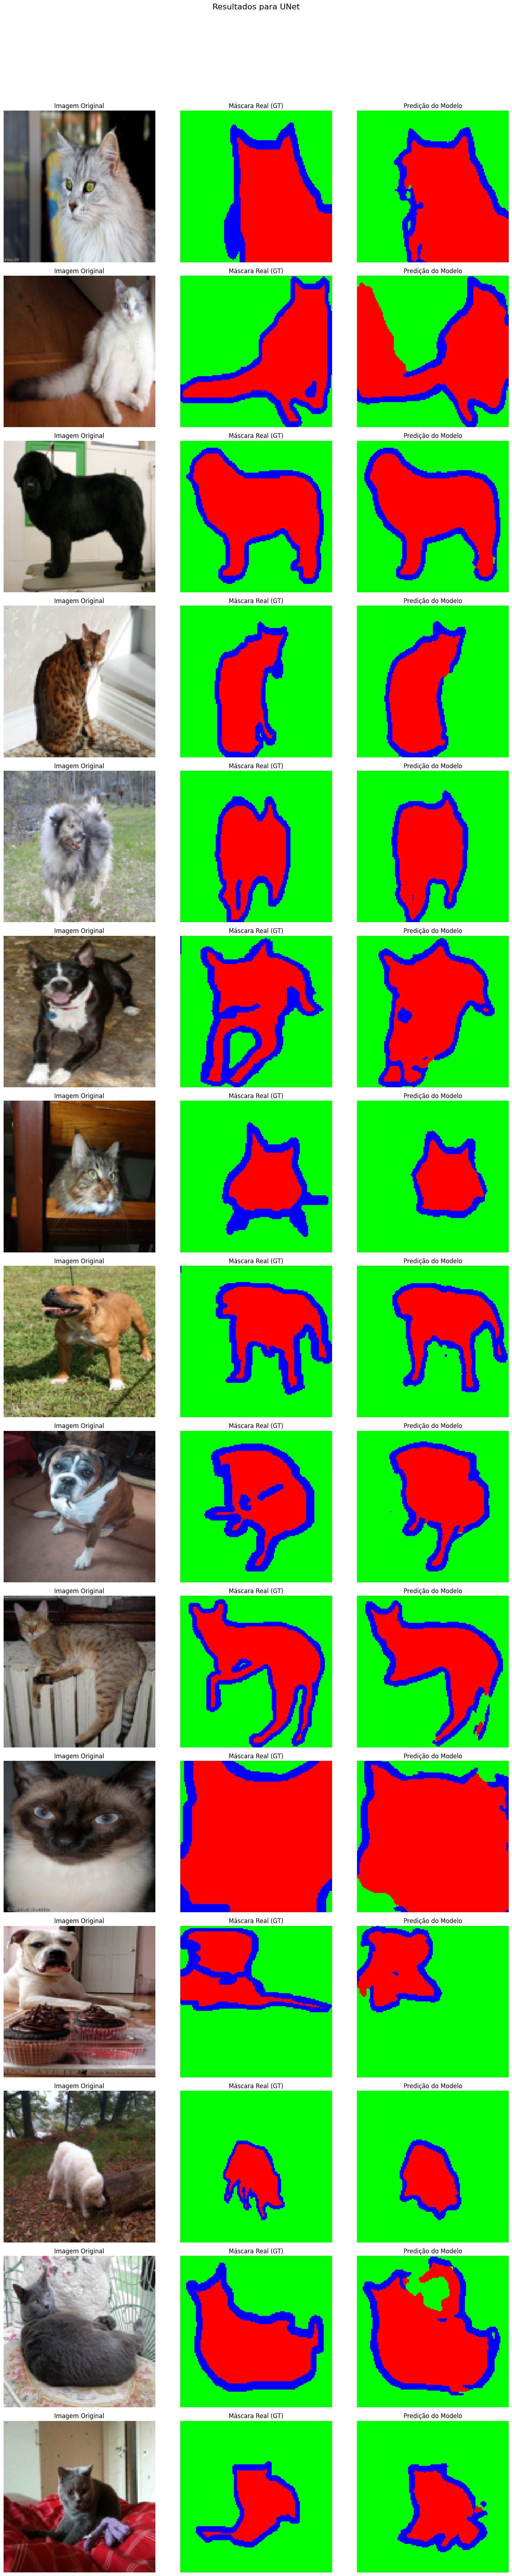

In [107]:
# Carregando os melhores pesos salvos durante o treino para garantir a melhor visualização
trained_unet.load_state_dict(torch.load("UNet_best.pth"))

# Visualizando os resultados da U-Net
print("--- Visualizando Preds da U-Net ---")
visualize_predictions(trained_unet, val_loader)


# Migração para .tflite

### 1. Migração para ONNX

In [ ]:
import torch

# 1. Carregar o modelo treinado
n_channels = 3
n_classes = 3
model = UNet(n_channels=n_channels, n_classes=n_classes)
model.load_state_dict(torch.load("UNet_best.pth")) # Carrega os melhores pesos que você salvou
model.eval() # IMPORTANTE: Colocar o modelo em modo de avaliação

# 2. Criar uma entrada "dummy" com o tamanho esperado pelo modelo
# O batch size deve ser 1, pois no app a inferência é por imagem.
# O tamanho da imagem deve ser 128x128, conforme o treino.
dummy_input = torch.randn(1, n_channels, 128, 128)

# 3. Exportar para ONNX
torch.onnx.export(model,
                  dummy_input,
                  "unet.onnx", 
                  export_params=True,
                  opset_version=11, # Versão do ONNX
                  do_constant_folding=True,
                  input_names = ['input'],
                  output_names = ['output'])

print("Modelo exportado para unet.onnx com sucesso!")

C:\Users\davieir4\AppData\Local\Temp\ipykernel_26404\575034101.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("UNet_best.pth")) # Carre

Modelo exportado para unet.onnx com sucesso!


### Devido a vários conflitos de dependências a migração foi completa no [colab]("https://colab.research.google.com/drive/1kYlApS8EvfunN8HOwZHe1sm1B86dMjMj?usp=sharing").

